In [6]:
# start by importing the necessary packages
import cv2
import os
import matplotlib.pyplot as plt
import json
import threading
import numpy as np
import matplotlib.cm as cm
from skimage import color, segmentation, measure, morphology, filters
from sklearn.cluster import KMeans
import pandas as pd
import os

# import the detector
from GMMDetector import MaterialDetector


def showImage(img):
    plt.figure(figsize=(10, 10))
    plt.axis("off")
    plt.imshow(img)

def whitebalance(image):
    # return image
    result = image.astype(np.float32)
    quantized = (image // 8) * 8
    brightness = quantized.sum(axis=2)
    mask = brightness > 30
    filtered = quantized[mask]
    
    colors_as_int = (filtered[:, 0].astype(np.int32) << 16) | (filtered[:, 1].astype(np.int32) << 8) | filtered[:, 2].astype(np.int32)
    
    counts = np.bincount(colors_as_int)
    most_common_int = np.argmax(counts)
    
    color = np.array([
        (most_common_int >> 16) & 0xFF,
        (most_common_int >> 8) & 0xFF,
        most_common_int & 0xFF
    ], dtype=np.float32)
    
    avg_gray = (color[0] + color[1] + color[2]) / 3.0
    scale_r = avg_gray / color[0] if color[0] > 0 else 1.0
    scale_g = avg_gray / color[1] if color[1] > 0 else 1.0
    scale_b = avg_gray / color[2] if color[2] > 0 else 1.0
    # print(f"Most common color: RGB({color[0]}, {color[1]}, {color[2]})")
    # print(f"Scale factors: R={scale_r:.3f}, G={scale_g:.3f}, B={scale_b:.3f}")
    result[:, :, 0] *= scale_r
    result[:, :, 1] *= scale_g
    result[:, :, 2] *= scale_b

    result = np.clip(result, 0, 255)
    return result.astype(np.uint8)

In [3]:
class CV_Functions:

    contrast_dict = {
        "1": {
            "contrast": {"b": -0.071, "g": -0.14, "r": -0.137},
            "covariance_matrix": [
                [0.00043690708813418295, 0.00013442550316341518, 3.640871553385172e-05],
                [0.00013442550316341518, 0.00023107833499992487, 9.354030315496938e-05],
                [3.640871553385172e-05, 9.354030315496936e-05, 0.0003320244165912582],
            ],
        },
        "2": {
            "contrast": {"b": -0.152, "g": -0.264, "r": -0.248},
            "covariance_matrix": [
                [0.0008328732295338676, 0.00025254658263370265, -0.00011751135771427775],
                [0.00025254658263370265, 0.0002369906495868485, 2.030565474167504e-05],
                [-0.00011751135771427775, 2.030565474167504e-05, 0.00031832333867950097],
            ],
        },
        "3": {
            "contrast": {"b": -0.216, "g": -0.368, "r": -0.347},
            "covariance_matrix": [
                [0.0013438145132320882, 0.0003876553710589909, -0.00017056175302890137],
                [0.0003876553710589909, 0.00027824710350493256, 1.567135606074001e-06],
                [-0.00017056175302890137, 1.5671356060739976e-06, 0.0003016258829573738],
            ],
        },
        "4": {
            "contrast": {"b": -0.272, "g": -0.465, "r": -0.436},
            "covariance_matrix": [
                [0.0010399285512173939, 0.00038128261246451735, 4.529938289991867e-05],
                [0.00038128261246451735, 0.0002952529548842852, 4.883854391652727e-05],
                [4.529938289991866e-05, 4.883854391652727e-05, 0.0002183833746245863],
            ],
        },
    }

    @staticmethod
    def matGMM2DTransform(img):
        flakes = CV_Functions.run_searching(img)

        CONFIDENCE_THRESHOLD = 0.5
        image = CV_Functions.visualise_flakes(
            flakes,
            img,
            confidence_threshold=CONFIDENCE_THRESHOLD,
        )
        return image

    @staticmethod
    def run_searching(img):
        model = MaterialDetector(
            contrast_dict=CV_Functions.contrast_dict,
            size_threshold=500,
            standard_deviation_threshold=5,
            used_channels="BGR",
        )

        flakes = model.detect_flakes(img)
        return flakes

    @staticmethod
    def visualise_flakes(flakes, image: np.ndarray, confidence_threshold: float = 0.5,) -> np.ndarray:
        """Visualise the flakes on the image.

        Args:
            flakes (List[Flake]): List of flakes to visualise.
            image (np.ndarray): Image to visualise the flakes on.
            confidence_threshold (float, optional): The confidence threshold to use, flakes with less confidence are not drawn. Defaults to 0.5.

        Returns:
            np.ndarray: Image with the flakes visualised.
        """

        confident_flakes = [
            flake
            for flake in flakes
            if (1 - flake.false_positive_probability) > confidence_threshold
        ]

        # get a colors for each flake
        colors = cm.rainbow(np.linspace(0, 1, len(confident_flakes)))[:, :3] * 255

        image = image.copy()
        for idx, flake in enumerate(confident_flakes):
            flake_contour = cv2.morphologyEx(
                flake.mask, cv2.MORPH_GRADIENT, np.ones((3, 3), np.uint8)
            )
            image[flake_contour > 0] = colors[idx]

            # put the text on the top right corner of the image
            cv2.putText(
                image,
                f"{(idx + 1):2}. {flake.thickness:1}L {int(flake.size * 0.3844**2):4}um2 {1- flake.false_positive_probability:.0%}",
                (10, 30 * (idx + 1)),
                cv2.QT_FONT_NORMAL,
                1,
                (255, 255, 255),
                2,
            )

            # draw a line from the text to the center of the flake
            cv2.line(
                image,
                (370, 30 * (idx + 1) - 15),
                (int(flake.center[0]), int(flake.center[1])),
                colors[idx],
                2,
            )

        return image

In [4]:
# Retry with performance tweaks:
# - Downscale large images for candidate discovery (return masks at downscaled size)
# - Faster ring computation using cv2 morphology
# - Fewer SLIC segments, smaller loops


def resize_if_large(img, max_dim=1600):
    h,w = img.shape[:2]
    scale = 1.0
    if max(h,w) > max_dim:
        scale = max_dim / max(h,w)
        img = cv2.resize(img, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_AREA)
    return img, scale

def gray_world_white_balance(img):
    img = img.astype(np.float32) + 1e-6
    means = img.reshape(-1,3).mean(axis=0)
    gain = means.mean()/means
    balanced = np.clip(img*gain, 0, 255).astype(np.uint8)
    return balanced

def kmeans_substrate_mask(img_rgb, k=4):
    lab = color.rgb2lab(img_rgb)
    h,w,_ = img_rgb.shape
    idx = np.random.choice(h*w, min(20000, h*w), replace=False)
    X = lab.reshape(-1,3)[idx]
    km = KMeans(n_clusters=k, n_init=3, random_state=0)
    km.fit(X)
    labels = km.predict(lab.reshape(-1,3)).reshape(h,w)
    areas = [(labels==i).sum() for i in range(k)]
    substrate_label = int(np.argmax(areas))
    return (labels==substrate_label), lab

def slic_superpixels(img_rgb, n_segments=1500, compactness=20):
    return segmentation.slic(img_rgb, n_segments=n_segments, compactness=compactness, start_label=1, channel_axis=2)

def polygonality_score(contour):
    peri = cv2.arcLength(contour, True)
    if peri == 0:
        return 0.0, 0, 0.0
    approx = cv2.approxPolyDP(contour, 0.015*peri, True)
    area = cv2.contourArea(contour)
    if area <= 0:
        return 0.0, 0, 0.0
    compactness = 4*np.pi*area/(peri*peri)
    k = len(approx)
    k_score = 1 - min(max(k-3,0),9)/9.0
    score = 0.6*k_score + 0.4*compactness
    return float(score), int(k), float(compactness)

def ring_mean_delta_lab(mask, lab, r=8):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*r+1, 2*r+1))
    m = (mask.astype(np.uint8)*255)
    dil = cv2.dilate(m, kernel)
    ring = ((dil>0) & (~mask))
    # thin the ring a bit
    er_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    ring = cv2.erode(ring.astype(np.uint8)*255, er_kernel)>0
    if ring.sum()==0:
        return np.array([np.nan, np.nan, np.nan])
    mean_ring = lab[ring].mean(axis=0)
    mean_core = lab[mask].mean(axis=0)
    return mean_core - mean_ring

def extract_flake_candidates_fast(img_rgb, min_area_px=120, max_area_frac=0.12):
    img_rgb, scale = resize_if_large(img_rgb, max_dim=2400)
    wb = img_rgb
    substrate_mask, lab = kmeans_substrate_mask(wb, k=4)
    non_sub = ~substrate_mask
    labels_cc = measure.label(non_sub, connectivity=2)
    gray = cv2.cvtColor(wb, cv2.COLOR_RGB2GRAY)

    feats = []
    masks = []
    H,W = gray.shape
    for region in measure.regionprops(labels_cc):
        area = region.area
        if area < min_area_px or area > max_area_frac*(H*W):
            continue
        mask = (labels_cc == region.label)
        m = (mask.astype(np.uint8)*255)
        contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            continue
        cnt = max(contours, key=cv2.contourArea)
        pscore, kcorn, compact = polygonality_score(cnt)
        if cv2.contourArea(cnt) < min_area_px:
            continue
        # texture/variance
        region_lab = lab[mask]
        var_lab = float(region_lab.var(axis=0).mean())
        # ring delta
        dlab = ring_mean_delta_lab(mask, lab, r=6)
        if not np.isfinite(dlab).all():
            continue
        delta_norm = float(np.linalg.norm(dlab))
        # heuristic score (tuned for speed)
        score = 0.45*pscore + 0.25*compact + 0.3*(1/(1+var_lab/100))
        accept = (pscore>0.35) and (compact>0.22)
        masks.append(mask)
        feats.append({
            "label_id": region.label,
            "area_px": int(area),
            "poly_score": float(pscore),
            "n_corners": int(kcorn),
            "compactness": float(compact),
            "var_lab": float(var_lab),
            "deltaL": float(dlab[0]),
            "deltaa": float(dlab[1]),
            "deltab": float(dlab[2]),
            "delta_norm": float(delta_norm),
            "accept_rule": bool(accept),
            "heuristic_score": float(score),
        })
    if(len(feats) == 0):
        print("No flakes found")
        return [], pd.DataFrame(), {}
    df = pd.DataFrame(feats).sort_values("heuristic_score", ascending=False).reset_index(drop=True)
    debug = {"wb": wb, "substrate_mask": substrate_mask.astype(np.uint8), "labels_cc": labels_cc}
    return masks, df, debug



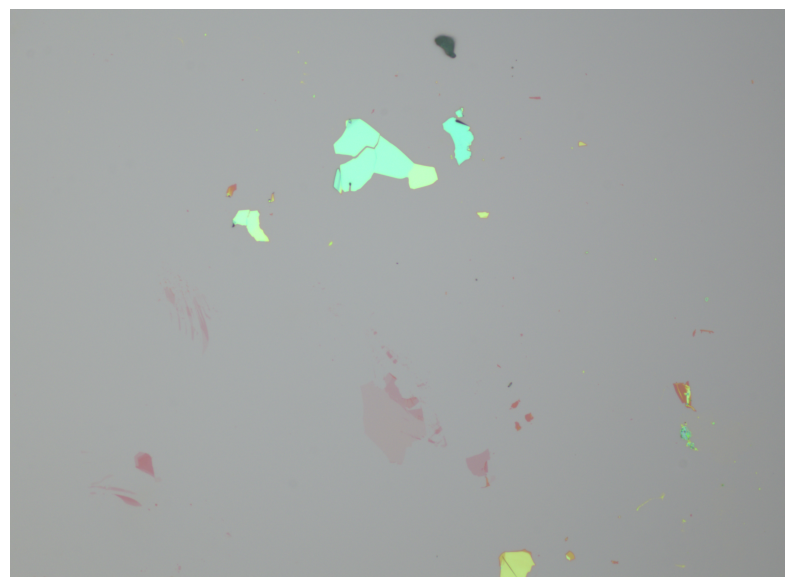

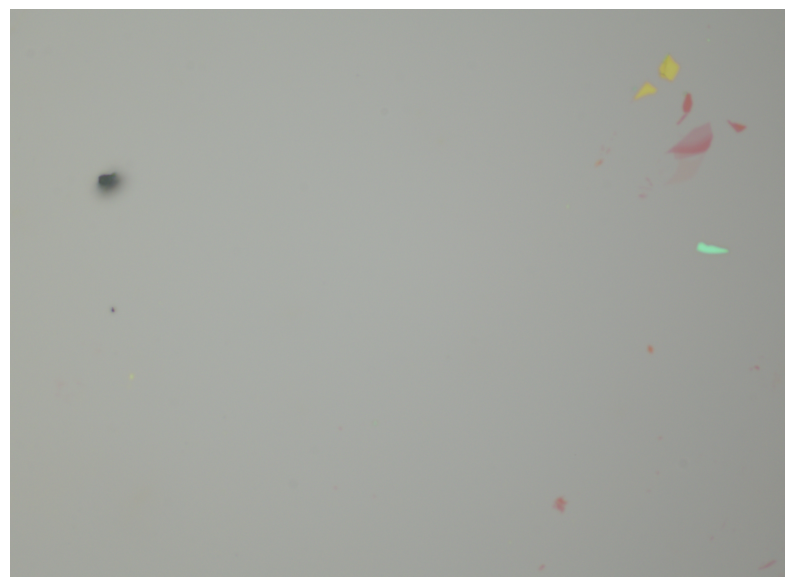

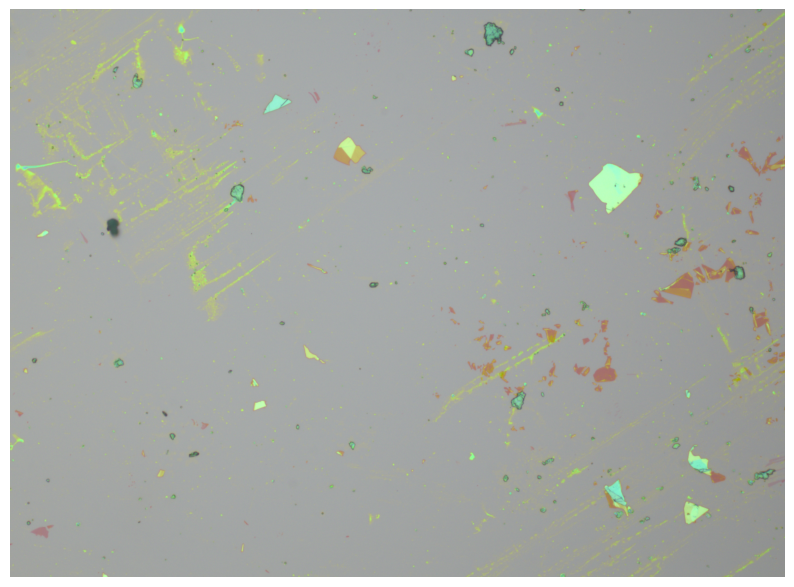

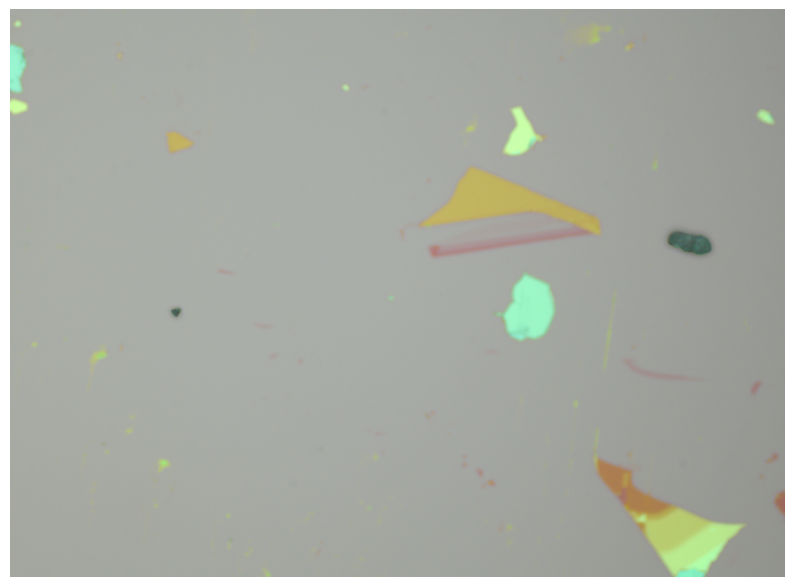

In [8]:
# image = cv2.imread("image.png", cv2.IMREAD_COLOR)
# image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
# image = whitebalance(image)
# # flakes = model.detect_flakes(image)
# showImage(image)

for i in range(4, 8):
    img_bgr = cv2.imread(f"images/image{i}.png")
    # img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    image = whitebalance(img_bgr)
    showImage(image)
    cv2.imwrite(f"images/imageW{i}.png", image)


In [6]:


# Run on the example image:
masks, df, debug = extract_flake_candidates_fast(image)

# Overlay top candidates
over = debug["wb"].copy()
overlay = over.copy()
topK = min(15, len(masks))
for i in range(topK):
    mask = masks[i]
    m = (mask.astype(np.uint8)*255)
    contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for c in contours:
        cv2.drawContours(overlay, [c], -1, (255,255,255), 2)
out = cv2.addWeighted(overlay, 0.6, over, 0.4, 0)

searched_image = CV_Functions.matGMM2DTransform(out)

/opt/homebrew/Caskroom/miniconda/base/envs/automatedTransfer/lib/python3.11/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.3.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [7]:
# Test the Flinder detector with example mask values

# Create detector instance
detector = FlinderDetector(use_high_contrast=False)

# Example mask values for graphene (you would get these from calibration data)
# Format: [kmin, kmax, bmin, bmax, gmin, gmax, rmin, rmax]
# These are example values - adjust based on your material calibration
mask_values_list = [
    # Monolayer example (adjust these values based on your calibration)
    [100, 150, 80, 120, 90, 130, 85, 125],
    # Bilayer example
    [90, 140, 70, 110, 80, 120, 75, 115],
    # Trilayer example
    [80, 130, 60, 100, 70, 110, 65, 105],
]

# Detect flakes
print("Running Flinder detection algorithm...")
flakes = detector.detect_flakes(image, mask_values_list, min_area=200)
print(f"Found {len(flakes)} flakes")

# Visualize results
vis_image = detector.visualize_flakes(image, flakes)

# Print details of detected flakes
for idx, flake in enumerate(flakes):
    stats = flake['stats']
    print(f"\nFlake {idx}:")
    print(f"  Thickness interval: {flake['interval_idx']}")
    print(f"  Area: {stats['area']:.0f} px")
    print(f"  Aspect ratio: {stats['aspect_ratio']:.2f}")
    print(f"  KBGR median: ({stats['k_median']:.0f}, {stats['b_median']:.0f}, "
          f"{stats['g_median']:.0f}, {stats['r_median']:.0f})")
    print(f"  KBGR std: ({stats['k_std']:.1f}, {stats['b_std']:.1f}, "
          f"{stats['g_std']:.1f}, {stats['r_std']:.1f})")

showImage(vis_image)


NameError: name 'FlinderDetector' is not defined